In [1]:
!g++ -std=c++17 decisionTree.cpp decisionTree_main.cpp -o decisionTree

In [2]:
import subprocess

result = subprocess.run(
    ["./decisionTree"],
    capture_output=True,
    text=True,
    check=True
)

print(result.stdout)
# Class 0 = edible, class 1 = poisonous

Dataset size: 8124
Train size:   6500
Test size:    1624

results on test subset (train / test split: 80% / 20%), random sample
Test size:            1624
Correct:              1583
Errors:               41

Confusion matrix:
TN: 823  FP: 31
FN: 10  TP: 760

Metrics:
Accuracy:             0.9748
Error rate:           0.0252
Precision:            0.9608
Recall:               0.9870
F1:                   0.9737
Specificity:          0.9637
Balanced accuracy:    0.9754

Saved:
mushroom_test_predictions.csv
mushroom_split.csv



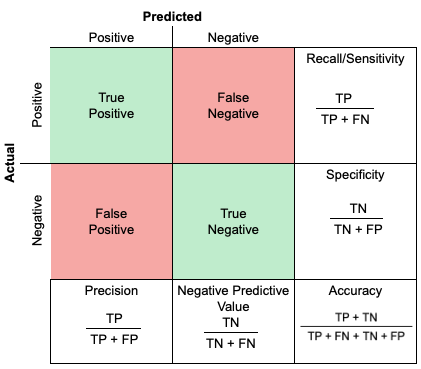 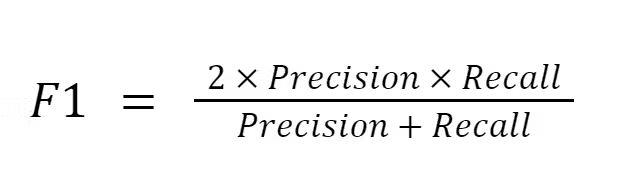

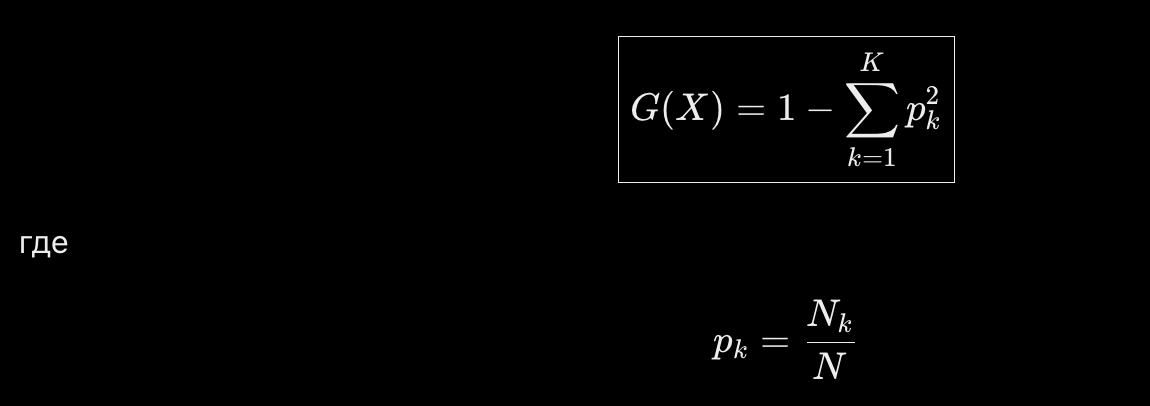 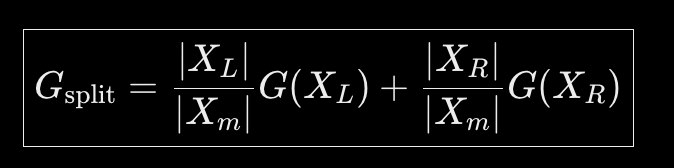 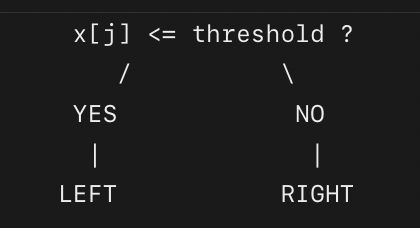

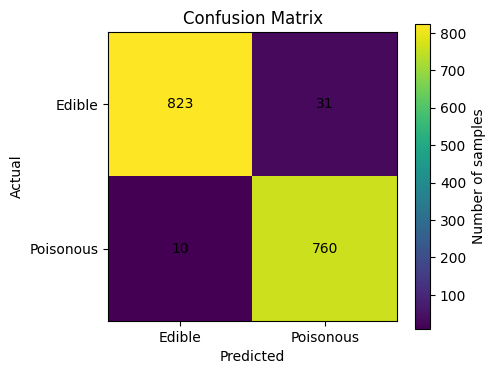

In [3]:
import csv
import subprocess
import matplotlib.pyplot as plt

y_true = []
y_pred = []
y_score = []

with open("mushroom_test_predictions.csv", newline="") as f:
    reader = csv.DictReader(f)

    for row in reader:
        y_true.append(int(row["true_label"]))
        y_pred.append(int(row["predicted_label"]))
        y_score.append(float(row["probability"]))


# Class 0 = edible, class 1 = poisonous

tp = sum(a == 1 and p == 1 for a, p in zip(y_true, y_pred))
tn = sum(a == 0 and p == 0 for a, p in zip(y_true, y_pred))
fp = sum(a == 0 and p == 1 for a, p in zip(y_true, y_pred))
fn = sum(a == 1 and p == 0 for a, p in zip(y_true, y_pred))

n = len(y_true)

accuracy = (tp + tn) / n
error_rate = (fp + fn) / n

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
specificity = tn / (tn + fp) if tn + fp else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall else 0
)

balanced_accuracy = (recall + specificity) / 2

#  confusion matrix

plt.figure(figsize=(5, 4))

matrix = [[tn, fp],
          [fn, tp]]

plt.imshow(matrix)

plt.xticks([0, 1], ["Edible", "Poisonous"])
plt.yticks([0, 1], ["Edible", "Poisonous"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, matrix[i][j],
                 ha="center", va="center")

plt.colorbar(label="Number of samples")
plt.tight_layout()
plt.show()


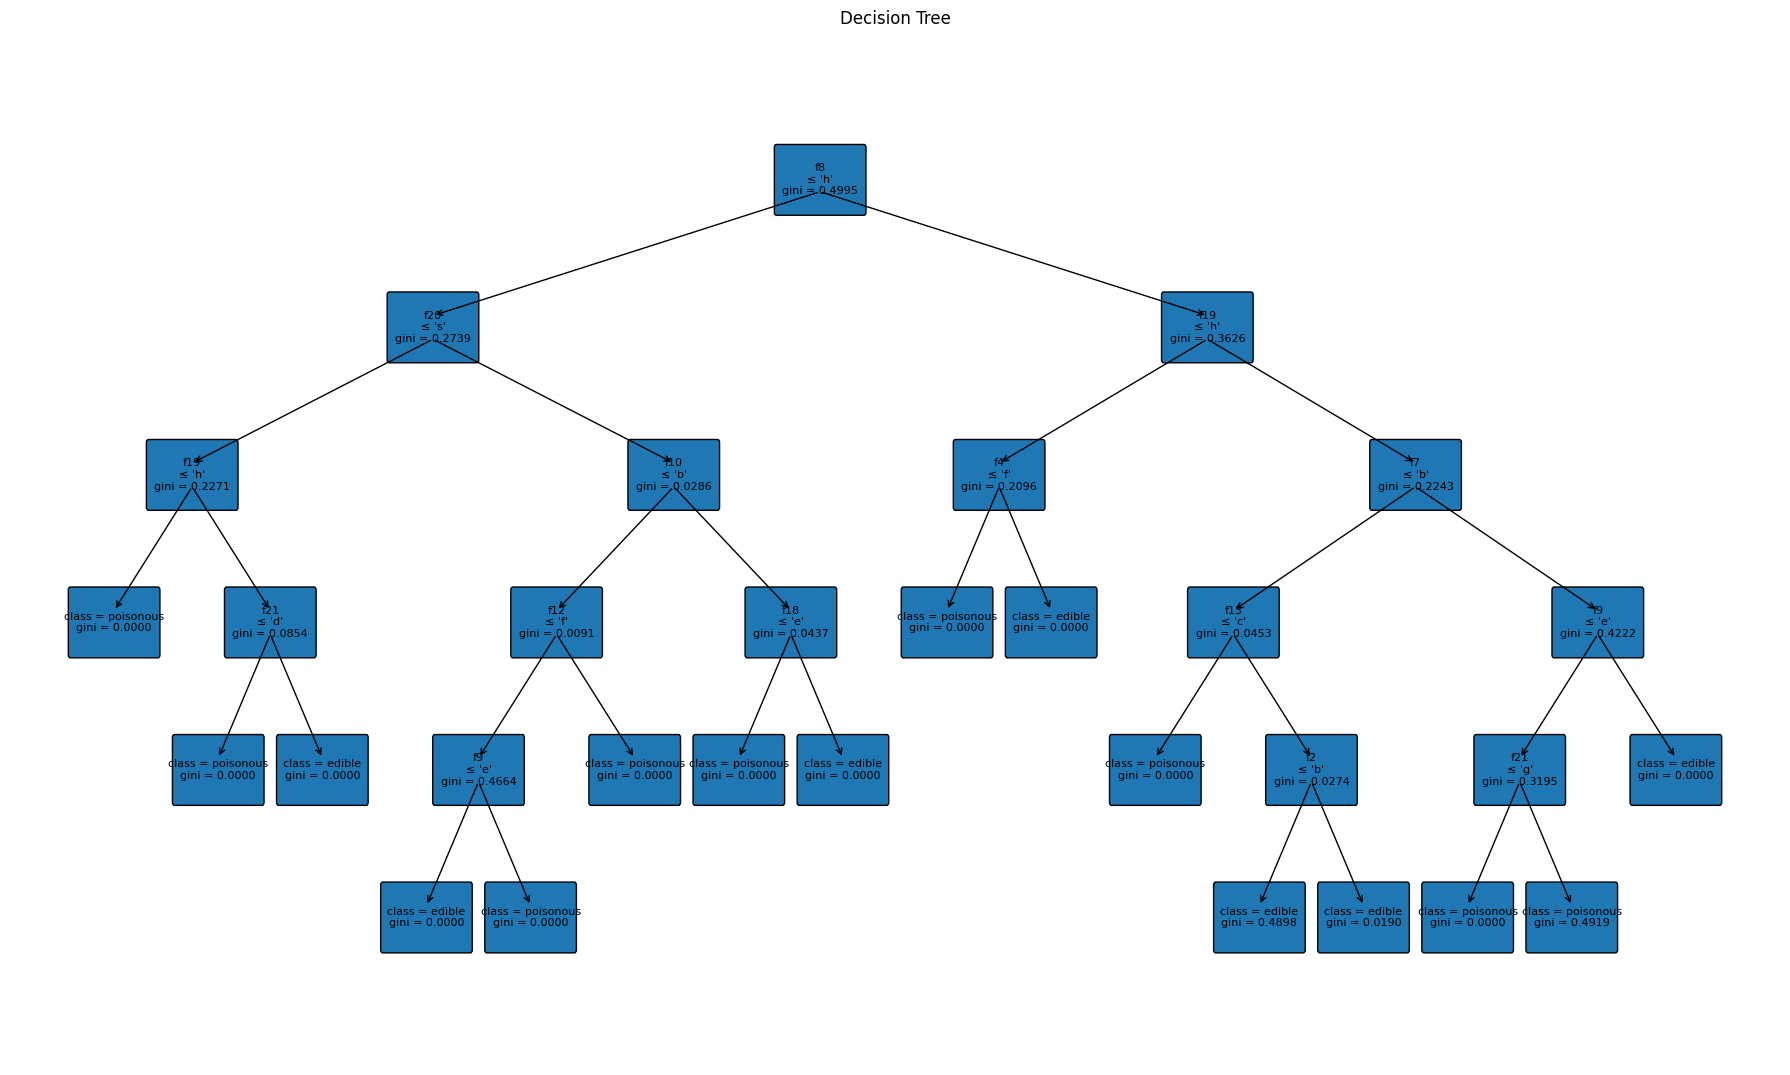

In [4]:
import re
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ============================================================
# Read linearized C++ tree
# ============================================================

#feature_names = [
#    "cap-shape", "cap-surface", "cap-color", "bruises",
#    "odor", "gill-attachment", "gill-spacing", "gill-size",
#    "gill-color", "stalk-shape", "stalk-root",
#    "stalk-surface-above-ring", "stalk-surface-below-ring",
#    "stalk-color-above-ring", "stalk-color-below-ring",
#    "veil-type", "veil-color", "ring-number", "ring-type",
#    "spore-print-color", "population", "habitat"
#]
feature_names = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10",
    "f11", "f12",
    "f13", "f14",
    "f15", "f16", "f17", "f18",
    "f19", "f20", "f21"
]

nodes = {}

with open("decision_tree.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        path, values = line.split(": ", 1)
        fields = dict(re.findall(r"(\w+)=([-.\d]+)", values))

        nodes[path] = {
            "split_feature": int(fields["split_feature"]),
            "threshold": float(fields["split_threshold"]),
            "gini": float(fields["gini"]),
            "leaf": float(fields["leaf_feature"]),
            "left_size": int(fields["left_size"]),
            "right_size": int(fields["right_size"]),
        }

# ============================================================
# Tree layout
# ============================================================

positions = {}
leaf_x = 0

def place(path, depth):
    global leaf_x

    node = nodes[path]

    if path + "L" in nodes:
        place(path + "L", depth + 1)

    if path + "L" not in nodes and path + "R" not in nodes:
        positions[path] = (leaf_x, -depth)
        leaf_x += 1

    if path + "R" in nodes:
        place(path + "R", depth + 1)

    if path + "L" in nodes or path + "R" in nodes:
        children = [
            positions[p]
            for p in (path + "L", path + "R")
            if p in positions
        ]
        positions[path] = (
            sum(x for x, _ in children) / len(children),
            -depth
        )

place("root", 0)

# ============================================================
# Draw tree
# ============================================================

fig, ax = plt.subplots(figsize=(18, max(6, len(nodes) * 0.35)))

# Edges
for path, (x, y) in positions.items():
    for child in (path + "L", path + "R"):
        if child in positions:
            cx, cy = positions[child]
            ax.annotate(
                "",
                xy=(cx, cy + 0.08),
                xytext=(x, y - 0.08),
                arrowprops=dict(arrowstyle="->", lw=1)
            )

# Nodes
for path, (x, y) in positions.items():
    node = nodes[path]

    if node["leaf"] >= 0:
        text = (
            f"class = {'poisonous' if node['leaf'] == 1 else 'edible'}\n"
            f"gini = {node['gini']:.4f}"
        )
    else:
        feature = node["split_feature"]
        threshold = round(node["threshold"])
        symbol = chr(threshold) if 32 <= threshold <= 126 else str(threshold)

        text = (
            f"{feature_names[feature]}\n"
            f"≤ '{symbol}'\n"
            f"gini = {node['gini']:.4f}"
        )

    box = FancyBboxPatch(
        (x - 0.42, y - 0.22),
        0.84, 0.44,
        boxstyle="round,pad=0.02",
        linewidth=1
    )

    ax.add_patch(box)
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=8
    )

ax.set_xlim(-1, leaf_x)
ax.set_ylim(-max(abs(y) for _, y in positions.values()) - 1, 1)
ax.axis("off")
ax.set_title("Decision Tree")
plt.tight_layout()
plt.show()

Accuracy:  0.9748
Precision: 0.9608
Recall:    0.9870
F1-score:  0.9737
TN=823, FP=31, FN=10, TP=760


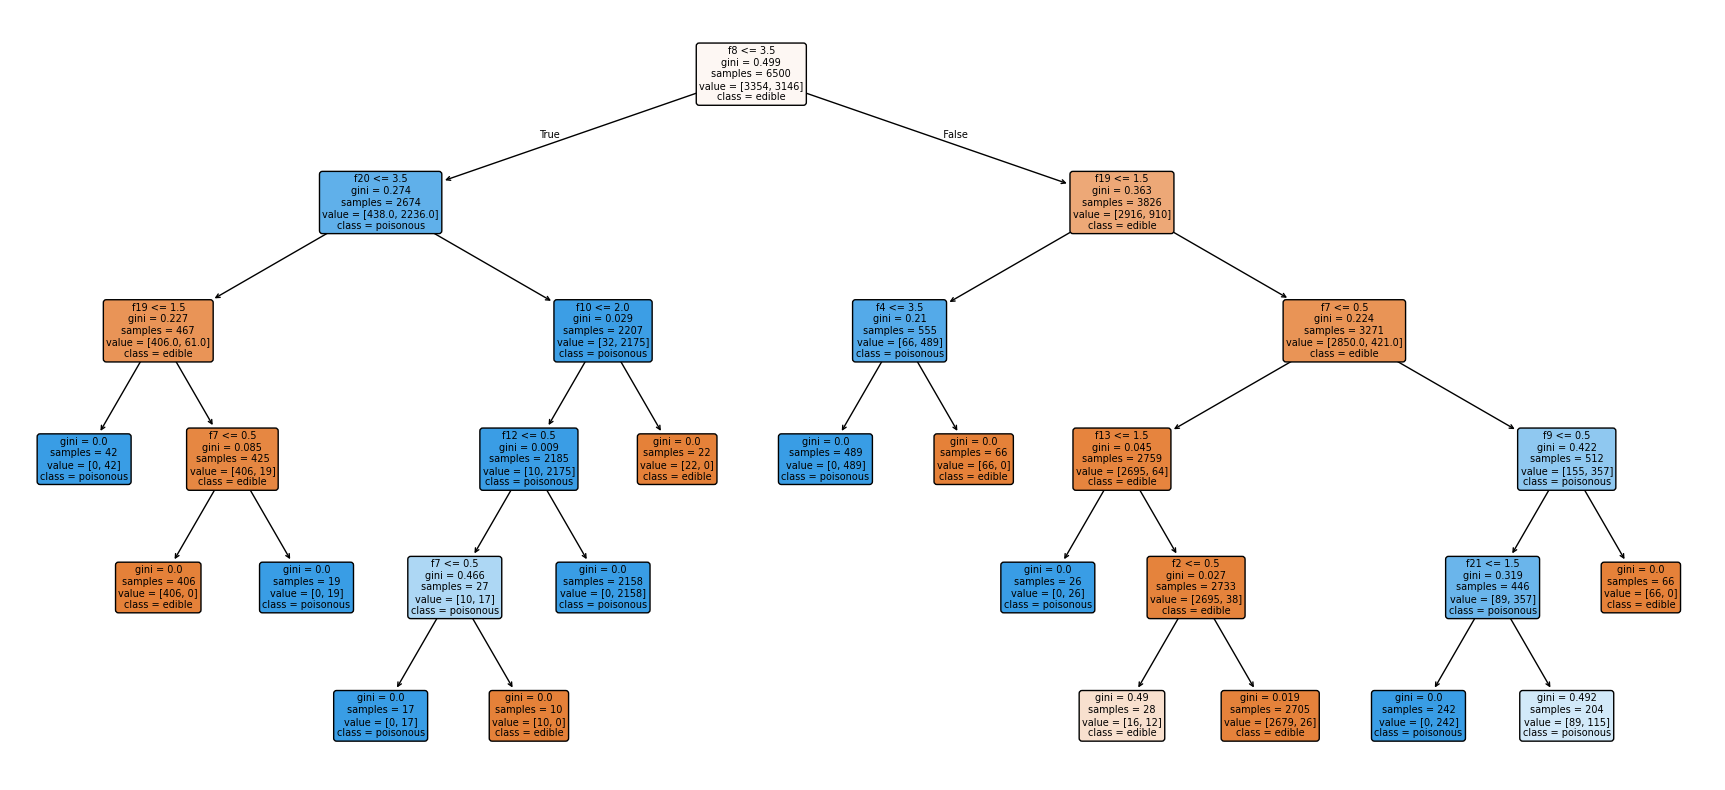

In [5]:
import csv
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X, y = [], []
with open("mushroom/agaricus-lepiota.data") as f:
    for row in csv.reader(f):
        y.append(1 if row[0] == "p" else 0)
        X.append(row[1:])

# the same train/test split
train_idx, test_idx = [], []
with open("mushroom_split.csv") as f:
    for row in csv.DictReader(f):
        (train_idx if row["split"] == "train" else test_idx).append(int(row["index"]))

enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
X_encoded = enc.fit_transform(X)

X_train = X_encoded[train_idx]
X_test = X_encoded[test_idx]
y_train = [y[i] for i in train_idx]
y_test = [y[i] for i in test_idx]

clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=666
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Tree visualization
plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    max_depth=5,
    filled=True,
    rounded=True,
    class_names=["edible", "poisonous"],
    feature_names=[f"f{i}" for i in range(22)],
    fontsize=7
)
plt.show()

#identical values !!!

In [6]:
!g++ -std=c++17 decisionTree.cpp randomForest.cpp randomForest_main.cpp -o randomForest

In [7]:
# task 2 : random forest, 50 trees - default value
import subprocess

subprocess.run([
    "g++", "-std=c++17",
    "decisionTree.cpp",
    "randomForest.cpp",
    "randomForest_main.cpp",
    "-o", "randomForest"
], check=True)

result = subprocess.run(
    ["./randomForest"],
    capture_output=True,
    text=True,
    check=True
)

print(result.stdout)

Trees:              50
Test size:          1624

Confusion matrix:
TN: 854  FP: 0
FN: 18  TP: 752

Metrics:
Accuracy:           0.9889
Error rate:         0.0111
Precision:          1.0000
Recall:             0.9766
F1:                 0.9882
Specificity:        1.0000
Balanced accuracy:  0.9883



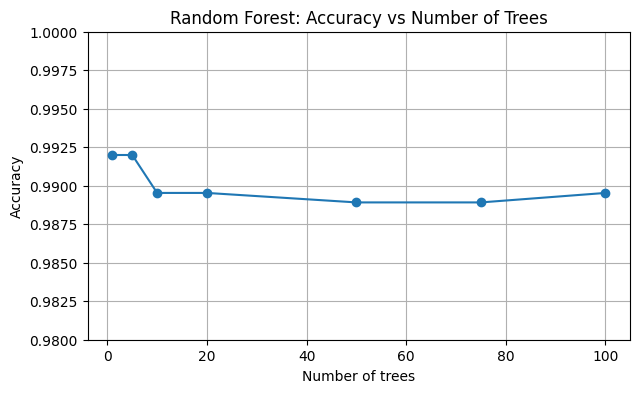

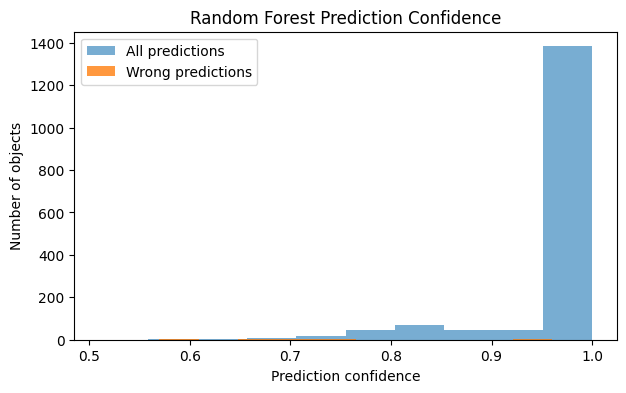

In [8]:
import csv
import subprocess
import matplotlib.pyplot as plt

# Accuracy vs number of trees plot

tree_counts = [1, 5, 10, 20, 50, 75, 100]
accuracies = []

for n in tree_counts:
    subprocess.run(["./randomForest", str(n)],
                   capture_output=True, text=True, check=True)

    true, pred, prob = [], [], []

    with open("random_forest_predictions.csv") as f:
        for row in csv.DictReader(f):
            true.append(int(row["true_label"]))
            pred.append(int(row["predicted_label"]))
            prob.append(float(row["probability"]))

    accuracies.append(
        sum(a == p for a, p in zip(true, pred)) / len(true)
    )

plt.figure(figsize=(7, 4))
plt.plot(tree_counts, accuracies, marker="o")
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees")
plt.ylim(0.98, 1)
plt.grid()
plt.show()

# Prediction confidence for 100-tree forest
# confidence = probability of the predicted class

confidence = [
    p if prediction == 1 else 1 - p
    for p, prediction in zip(prob, pred)
]

wrong_confidence = [
    c for c, actual, prediction
    in zip(confidence, true, pred)
    if actual != prediction
]

plt.figure(figsize=(7, 4))

plt.hist(confidence, bins=10, alpha=0.6, label="All predictions")
plt.hist(wrong_confidence, bins=10, alpha=0.8, label="Wrong predictions")

plt.xlabel("Prediction confidence")
plt.ylabel("Number of objects")
plt.title("Random Forest Prediction Confidence")
plt.legend()
plt.show()

In [9]:
#sklearn random forest
import csv
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix
)

# same parameters 
forest = RandomForestClassifier(
    n_estimators=50,
    criterion="gini",
    max_depth=5,
    max_features=5,
    bootstrap=True,
    random_state=666
)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
y_prob = forest.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)
balanced = balanced_accuracy_score(y_test, y_pred)

print("sklearn Random Forest")
print(f"Trees:              {forest.n_estimators}")
print(f"TN: {tn}  FP: {fp}")
print(f"FN: {fn}  TP: {tp}")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1:                 {f1:.4f}")
print(f"Specificity:        {specificity:.4f}")
print(f"Balanced accuracy:  {balanced:.4f}")

sklearn Random Forest
Trees:              50
TN: 854  FP: 0
FN: 14  TP: 756
Accuracy:           0.9914
Precision:          1.0000
Recall:             0.9818
F1:                 0.9908
Specificity:        1.0000
Balanced accuracy:  0.9909


In [10]:
!g++ -std=c++17 decisionTree.cpp AdaBoost.cpp AdaBoost_main.cpp -o AdaBoost

In [11]:
!./AdaBoost 50

Estimators:          50

Confusion matrix:
TN: 853  FP: 1
FN: 15  TP: 755

Metrics:
Accuracy:           0.9901
Error rate:         0.0099
Precision:          0.9987
Recall:             0.9805
F1:                 0.9895
Specificity:        0.9988
Balanced accuracy:  0.9897


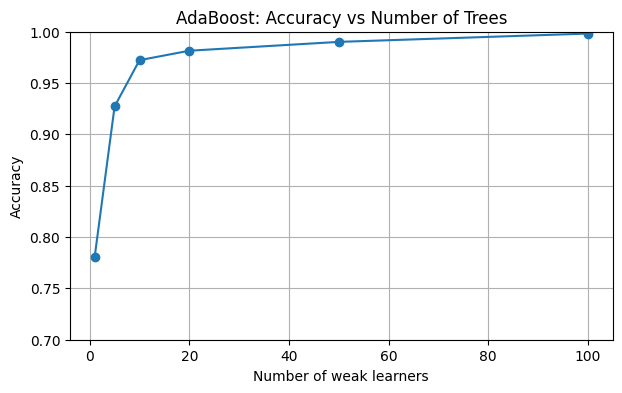

  1 trees: 0.7808
  5 trees: 0.9273
 10 trees: 0.9723
 20 trees: 0.9815
 50 trees: 0.9901
100 trees: 0.9982


In [12]:
import subprocess
import re
import matplotlib.pyplot as plt

estimators = [1, 5, 10, 20, 50, 100]
accuracies = []

for n in estimators:
    result = subprocess.run(
        ["./AdaBoost", str(n)],
        capture_output=True,
        text=True,
        check=True
    )

    accuracy = float(
        re.search(r"Accuracy:\s+([0-9.]+)", result.stdout).group(1)
    )

    accuracies.append(accuracy)

plt.figure(figsize=(7, 4))
plt.plot(estimators, accuracies, marker="o")
plt.xlabel("Number of weak learners")
plt.ylabel("Accuracy")
plt.title("AdaBoost: Accuracy vs Number of Trees")
plt.ylim(0.7, 1)
plt.grid()
plt.show()

for n, acc in zip(estimators, accuracies):
    print(f"{n:3d} trees: {acc:.4f}")

In [13]:
#sklearn AdaBoost
import csv
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix
)

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        criterion="gini",
        random_state=666
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=666
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)
balanced = balanced_accuracy_score(y_test, y_pred)

print("sklearn AdaBoost")
print(f"Estimators:          {len(model.estimators_)}")
print(f"TN: {tn}  FP: {fp}")
print(f"FN: {fn}  TP: {tp}")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Error rate:         {1 - accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1:                 {f1:.4f}")
print(f"Specificity:        {specificity:.4f}")
print(f"Balanced accuracy:  {balanced:.4f}")

sklearn AdaBoost
Estimators:          50
TN: 854  FP: 0
FN: 5  TP: 765
Accuracy:           0.9969
Error rate:         0.0031
Precision:          1.0000
Recall:             0.9935
F1:                 0.9967
Specificity:        1.0000
Balanced accuracy:  0.9968
